## Comparsion of Kernels

### Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### import Skitlearn

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
     accuracy_score, classification_report, confusion_matrix
) 

### Create Non-linear Data

In [3]:
x, y = make_moons(
    n_samples=400,
    noise=0.25,
    random_state=42
)

## Train and Test Split

In [4]:
X_train,X_test,y_train,y_test=train_test_split(
     x,y,
     test_size=0.25,stratify=y,random_state=42
)

### Defining Models

In [5]:
models = {
    "Linear SVM": SVC(kernel="linear", C=1),
    "Polynomial SVM": SVC(kernel="poly", degree=3, C=1, gamma="scale"),
    "RBF SVM": SVC(kernel="rbf", C=1, gamma="scale")
}

### Model training and Evaluation

In [6]:
for name, svm_model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", svm_model)
    ])

    pipe.fit(X_train, y_train)

    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("Training accuracy:", accuracy_score(y_train, train_pred))
    print("Testing accuracy :", accuracy_score(y_test, test_pred))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, test_pred))
    print("Classification report:")
    print(classification_report(y_test, test_pred))


Linear SVM
Training accuracy: 0.8133333333333334
Testing accuracy : 0.92
Confusion matrix:
[[46  4]
 [ 4 46]]
Classification report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        50
           1       0.92      0.92      0.92        50

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100


Polynomial SVM
Training accuracy: 0.8066666666666666
Testing accuracy : 0.89
Confusion matrix:
[[48  2]
 [ 9 41]]
Classification report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.90        50
           1       0.95      0.82      0.88        50

    accuracy                           0.89       100
   macro avg       0.90      0.89      0.89       100
weighted avg       0.90      0.89      0.89       100


RBF SVM
Training accuracy: 0.91
Testing accuracy : 0.95
Confusion matrix:

### Visualize Decision Boundaries

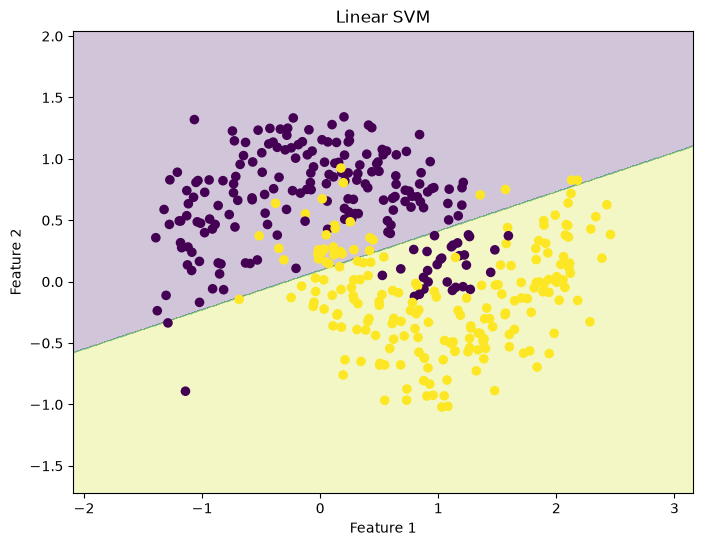

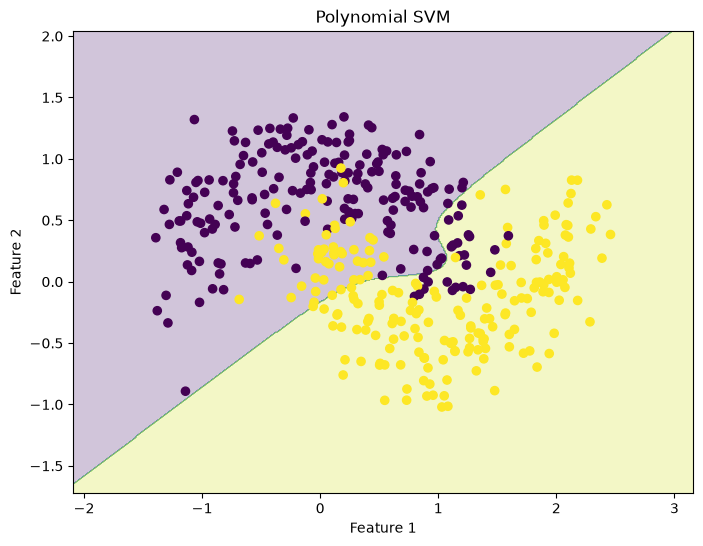

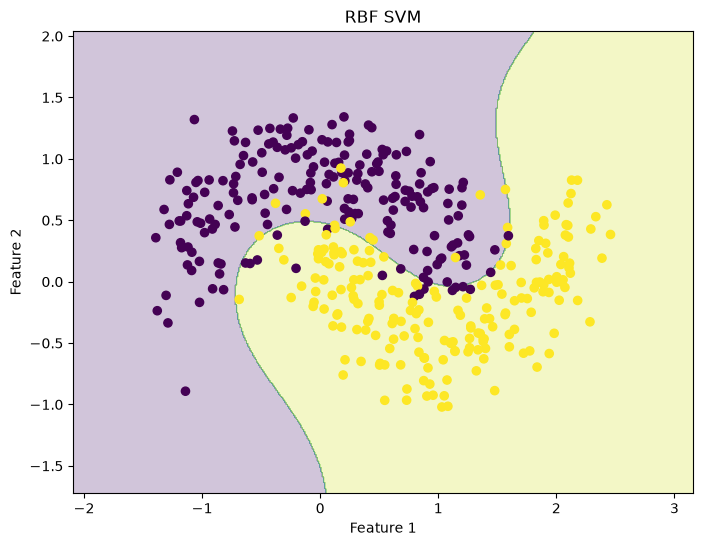

In [8]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    predictions = model.predict(grid)
    predictions = predictions.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, predictions, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=35)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


for name, svm_model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", svm_model)
    ])

    pipe.fit(X_train, y_train)
    plot_decision_boundary(pipe, x, y, name)

## Experiment with `c`

In [11]:
c_values = [0.01, 0.1, 1, 10, 100]
results=[]
for c in c_values:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=c, gamma="scale"))
    ])

    pipe.fit(X_train, y_train)

    train_acc = pipe.score(X_train, y_train)
    test_acc = pipe.score(X_test, y_test)
    results.append({
        "C": c,
        "Train Accuracy": round(train_acc, 3),
        "Test Accuracy": round(test_acc, 3),
        "Support Vectors": len(
        pipe.named_steps["model"].support_vectors_
    )
    })

# Create DataFrame
results_df = pd.DataFrame(results)

print(results_df)

        C  Train Accuracy  Test Accuracy  Support Vectors
0    0.01           0.823           0.94              300
1    0.10           0.883           0.96              169
2    1.00           0.910           0.95               98
3   10.00           0.937           0.92               65
4  100.00           0.960           0.92               51


### Experiment With Gamma

In [14]:
gamma_values = [0.01, 0.1, 1, 10, 100]
result=[]
for gamma in gamma_values:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1, gamma=gamma))
    ])

    pipe.fit(X_train, y_train)

    train_acc = pipe.score(X_train, y_train)
    test_acc = pipe.score(X_test, y_test)

    result.append({
        "Gamma": gamma,
        "Train Accuracy": round(train_acc, 3),
        "Test Accuracy": round(test_acc, 3),
        "Support Vectors": len(
        pipe.named_steps["model"].support_vectors_)
    })
result_df = pd.DataFrame(result)

print(result_df)

    Gamma  Train Accuracy  Test Accuracy  Support Vectors
0    0.01           0.810           0.93              173
1    0.10           0.820           0.95              134
2    1.00           0.937           0.93               87
3   10.00           0.960           0.90              162
4  100.00           0.990           0.90              284


### `c` and `gamma` grid 

In [18]:
res= []
for c in [0.1, 1, 10, 100]:
    for gamma in [0.01, 0.1, 1, 10]:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", C=c, gamma=gamma))
        ])

        pipe.fit(X_train, y_train)

        train_acc = pipe.score(X_train, y_train)
        test_acc = pipe.score(X_test, y_test)

        res.append({
            "C": c,
            "gamma": gamma,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "gap": train_acc - test_acc
        })

res_df=pd.DataFrame(res)
print(res_df)

        C  gamma  train_accuracy  test_accuracy       gap
0     0.1   0.01        0.800000           0.93 -0.130000
1     0.1   0.10        0.813333           0.94 -0.126667
2     0.1   1.00        0.906667           0.96 -0.053333
3     0.1  10.00        0.950000           0.92  0.030000
4     1.0   0.01        0.810000           0.93 -0.120000
5     1.0   0.10        0.820000           0.95 -0.130000
6     1.0   1.00        0.936667           0.93  0.006667
7     1.0  10.00        0.960000           0.90  0.060000
8    10.0   0.01        0.813333           0.93 -0.116667
9    10.0   0.10        0.883333           0.96 -0.076667
10   10.0   1.00        0.956667           0.92  0.036667
11   10.0  10.00        0.973333           0.90  0.073333
12  100.0   0.01        0.816667           0.92 -0.103333
13  100.0   0.10        0.926667           0.94 -0.013333
14  100.0   1.00        0.960000           0.89  0.070000
15  100.0  10.00        0.993333           0.93  0.063333
